
# COMS4732 HW4 — Part 1: Fit a Neural Field to a 2D Image

- load one image
- build a coordinate -> RGB neural field
- apply **sinusoidal positional encoding**
- train an **MLP** with **MSE loss** and **Adam**
- compute **PSNR**
- visualize reconstructions at different iterations
- run a **2×2 hyperparameter grid** over positional encoding frequency and network width

In [3]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps



## 1. Load and visualize an image

Set `IMAGE_PATH` to the provided assignment image or to your own image.

A smaller image will train much faster, so you can optionally resize it with `MAX_DIM`.


Image shape: (689, 1024, 3)


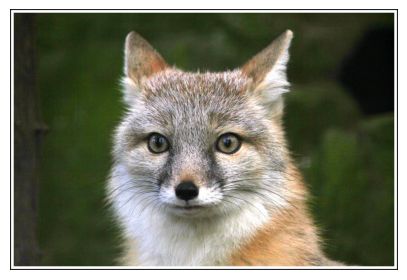

In [4]:
IMAGE_PATH = "data/animal.jpg"
MAX_DIM = None # set to None to keep original size

def load_image(image_path, max_dim=None):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    img = Image.open(image_path).convert("RGB")

    if max_dim is not None:
        w, h = img.size
        scale = min(1.0, max_dim / max(w, h))
        if scale < 1.0:
            new_w = max(1, int(round(w * scale)))
            new_h = max(1, int(round(h * scale)))
            img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    img_np = np.asarray(img, dtype=np.float32) / 255.0
    return img_np

image_np = load_image(IMAGE_PATH, MAX_DIM)
print("Image shape:", image_np.shape)
plt.figure(figsize=(5, 5))
plt.imshow(image_np)
plt.axis("off")
plt.show()


## 2. Build coordinates and a dataloader

Each pixel becomes one training example:

- input: normalized coordinate `(x / W, y / H)`
- target: normalized RGB value in `[0, 1]`

The model takes 2D coordinates and predicts RGB.

In [5]:

class PixelDataset(Dataset):
    def __init__(self, image_np):
        self.image_np = image_np.astype(np.float32)
        self.h, self.w, _ = self.image_np.shape

        # creating normalised coordinate grid
        ys = torch.arange(self.h, dtype=torch.float32) / float(self.h)
        xs = torch.arange(self.w, dtype=torch.float32) / float(self.w)
        y_grid, x_grid = torch.meshgrid(ys, xs, indexing="ij")

        # stacking and reshaping to get (num_pixels, 2) shape for coordinates and (num_pixels, 3) for RGB values
        self.coords = torch.stack([x_grid, y_grid], dim=-1).reshape(-1, 2)
        self.rgbs = torch.from_numpy(self.image_np).reshape(-1, 3)

    def __len__(self):
        # number of pixels in the image
        return self.coords.shape[0]

    def __getitem__(self, idx):
        # returning the coordinate and RGB value for the given index
        return self.coords[idx], self.rgbs[idx]


def make_dataloader(image_np, batch_size=10000):
    dataset = PixelDataset(image_np)
    loader = DataLoader(
        dataset,
        batch_size=min(batch_size, len(dataset)),
        shuffle=True,
        num_workers=0,
        drop_last=False,
    )
    return dataset, loader



## 3. Positional encoding

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, in_dim=2, num_freqs=10, include_input=True):
        super().__init__()
        self.in_dim = in_dim # input dimension - 2 for (x, y) coordinates
        self.num_freqs = num_freqs # number of frequency bands to use for encoding
        self.include_input = include_input # whether to include the original input in the output encoding

        self.out_dim = 0
        if include_input:
            self.out_dim += in_dim
        self.out_dim += 2 * in_dim * num_freqs

    def forward(self, x):
        outputs = []
        if self.include_input:
            outputs.append(x)

        for k in range(self.num_freqs):
            freq = (2.0 ** k) * math.pi
            outputs.append(torch.sin(freq * x))
            outputs.append(torch.cos(freq * x))

        return torch.cat(outputs, dim=-1)


## 4. MLP neural field
Architecture:
- positional encoding
- linear → ReLU
- linear → ReLU
- linear → ReLU
- linear → Sigmoid

Sigmoid keeps RGB outputs in `[0, 1]`.

In [7]:
class NeuralField2D(nn.Module):
    def __init__(self, num_freqs=10, hidden_dim=256):
        super().__init__()

        # Positional encoding layer
        self.pe = PositionalEncoding(in_dim=2, num_freqs=num_freqs, include_input=True)

        # After positional encoding, input size becomes 42 when num_freqs=10
        in_dim = self.pe.out_dim

        # MLP layers
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, 3)

        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, coords):
        x = self.pe(coords)  # Step 1: positional encoding
        x = self.relu(self.fc1(x))  # Step 2: first hidden layer
        x = self.relu(self.fc2(x))  # Step 3: second hidden layer
        x = self.relu(self.fc3(x))  # Step 4: third hidden layer
        x = self.sigmoid(self.fc4(x))  # Step 5: output RGB in [0, 1]
        return x


## 5. Utility functions

PSNR is computed from MSE using:

$$
PSNR = 10 \log_{10}\left(\frac{1}{MSE}\right)
$$

since pixel values are normalized to `[0, 1]`.


In [8]:

def mse_to_psnr(mse):
    mse = max(float(mse), 1e-12)
    return 10.0 * math.log10(1.0 / mse)


@torch.no_grad()
def render_full_image(model, h, w, device, chunk_size=65536):
    model.eval()

    ys = torch.arange(h, dtype=torch.float32, device=device) / float(h)
    xs = torch.arange(w, dtype=torch.float32, device=device) / float(w)
    y_grid, x_grid = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([x_grid, y_grid], dim=-1).reshape(-1, 2)

    preds = []
    for start in range(0, coords.shape[0], chunk_size):
        chunk = coords[start:start + chunk_size]
        preds.append(model(chunk).detach().cpu())

    pred = torch.cat(preds, dim=0).reshape(h, w, 3).numpy()
    return np.clip(pred, 0.0, 1.0)


def show_image(img, title=None, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(np.clip(img, 0.0, 1.0))
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()


def show_progress_grid(gt_image, checkpoints):
    steps = sorted(checkpoints.keys())
    num_cols = len(steps) + 1

    fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4))
    axes[0].imshow(gt_image)
    axes[0].set_title("Ground truth")
    axes[0].axis("off")

    for ax, step in zip(axes[1:], steps):
        ax.imshow(checkpoints[step]["image"])
        ax.set_title(f"iter {step}\nPSNR={checkpoints[step]['psnr']:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 6. Training loop

Default settings"

- loss: `MSELoss`
- optimizer: `Adam`
- learning rate: `1e-2`
- batch size: `10000`
- number of iterations: `2000`

In [15]:
def train_neural_field(
    image_np,
    num_freqs=10,
    hidden_dim=256,
    lr=1e-2,
    batch_size=10000,
    num_iters=2000,
    eval_every=100,
    checkpoint_steps=(1, 100, 500, 1000, 2000),
):
    dataset, loader = make_dataloader(image_np, batch_size=batch_size)
    h, w = dataset.h, dataset.w

    model = NeuralField2D(
        num_freqs=num_freqs,
        hidden_dim=hidden_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {
        "iter": [],
        "batch_mse": [],
        "batch_psnr": [],
        "eval_iter": [],
        "eval_psnr": [],
    }

    checkpoints = {}
    loader_iter = iter(loader)
    checkpoint_steps = set(checkpoint_steps)

    last_recon = None
    last_psnr = None

    for step in range(1, num_iters + 1):
        model.train()

        try:
            coords, rgbs = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loader)
            coords, rgbs = next(loader_iter)

        coords = coords.to(device)
        rgbs = rgbs.to(device)

        optimizer.zero_grad(set_to_none=True)
        preds = model(coords)
        loss = criterion(preds, rgbs)
        loss.backward()
        optimizer.step()

        batch_mse = loss.item()
        batch_psnr = mse_to_psnr(batch_mse)

        history["iter"].append(step)
        history["batch_mse"].append(batch_mse)
        history["batch_psnr"].append(batch_psnr)

        needs_eval = (
            (step % eval_every == 0)
            or (step in checkpoint_steps)
            or (step == num_iters)
        )
        if needs_eval:
            recon = render_full_image(model, h, w, device=device)
            full_mse = np.mean((recon - image_np) ** 2)
            full_psnr = mse_to_psnr(full_mse)

            history["eval_iter"].append(step)
            history["eval_psnr"].append(full_psnr)

            if step in checkpoint_steps:
                checkpoints[step] = {
                    "image": recon,
                    "mse": float(full_mse),
                    "psnr": float(full_psnr),
                }

            last_recon = recon
            last_psnr = full_psnr

            print(
                f"iter {step:4d} | batch MSE: {batch_mse:.6f} | "
                f"batch PSNR: {batch_psnr:.2f} | full PSNR: {full_psnr:.2f}"
            )

    return model, history, checkpoints, last_recon, last_psnr

## 7. Baseline run on one image

Image shape: (689, 1024, 3)


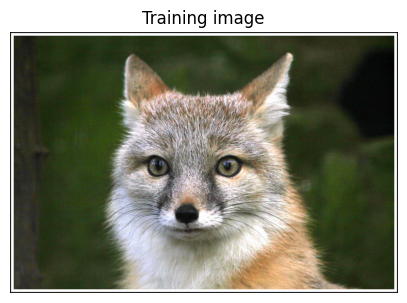

iter    1 | batch MSE: 0.103610 | batch PSNR: 9.85 | full PSNR: 8.73
iter  100 | batch MSE: 0.007443 | batch PSNR: 21.28 | full PSNR: 21.67
iter  200 | batch MSE: 0.004137 | batch PSNR: 23.83 | full PSNR: 24.14
iter  300 | batch MSE: 0.003610 | batch PSNR: 24.42 | full PSNR: 24.67
iter  400 | batch MSE: 0.003190 | batch PSNR: 24.96 | full PSNR: 25.06
iter  500 | batch MSE: 0.003082 | batch PSNR: 25.11 | full PSNR: 25.30
iter  600 | batch MSE: 0.003058 | batch PSNR: 25.15 | full PSNR: 25.46
iter  700 | batch MSE: 0.002822 | batch PSNR: 25.49 | full PSNR: 25.56
iter  800 | batch MSE: 0.002695 | batch PSNR: 25.69 | full PSNR: 25.64
iter  900 | batch MSE: 0.002601 | batch PSNR: 25.85 | full PSNR: 25.83
iter 1000 | batch MSE: 0.002529 | batch PSNR: 25.97 | full PSNR: 25.81
iter 1100 | batch MSE: 0.002552 | batch PSNR: 25.93 | full PSNR: 25.99
iter 1200 | batch MSE: 0.002641 | batch PSNR: 25.78 | full PSNR: 26.08
iter 1300 | batch MSE: 0.002490 | batch PSNR: 26.04 | full PSNR: 26.14
iter 140

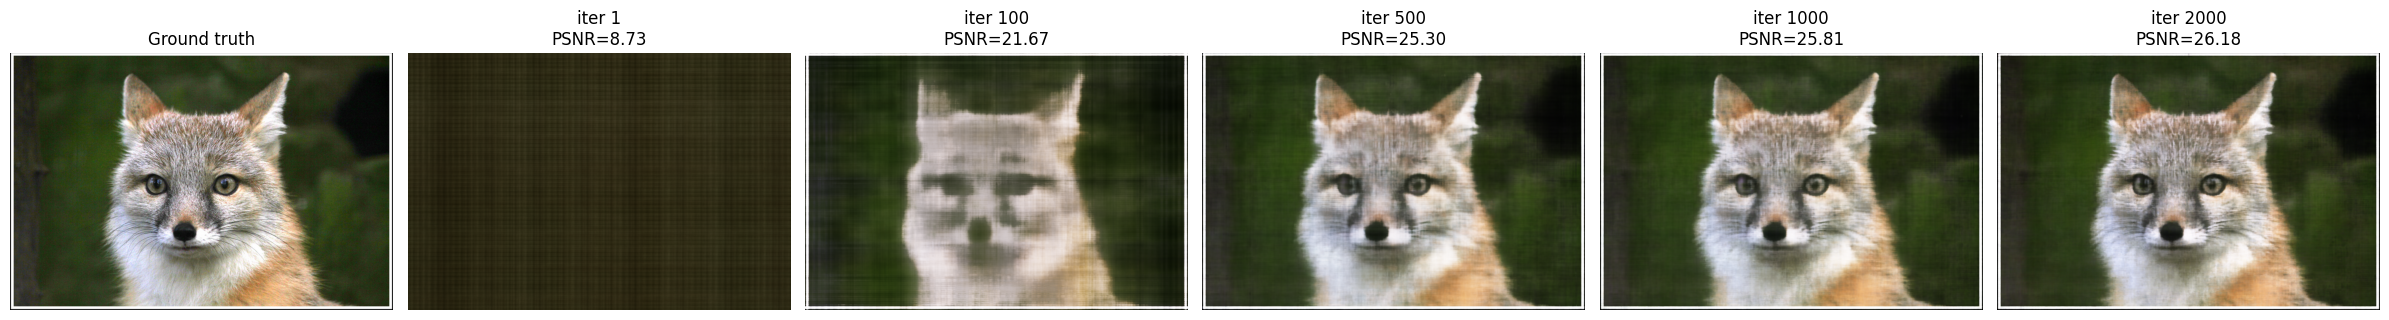

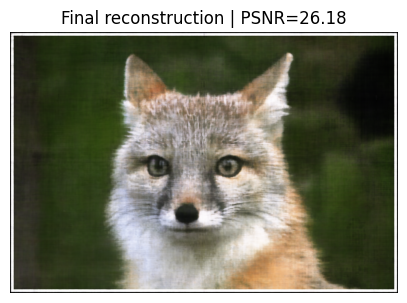

In [16]:
image_np = load_image(IMAGE_PATH, MAX_DIM)
print("Image shape:", image_np.shape)
show_image(image_np, title="Training image")

baseline_config = {
    "num_freqs": 10,
    "hidden_dim": 256,
    "lr": 1e-2,
    "batch_size": 10000,
    "num_iters": 2000,
    "eval_every": 100,
    "checkpoint_steps": (1, 100, 500, 1000, 2000),
}

model, history, checkpoints, final_recon, final_psnr = train_neural_field(
    image_np,
    **baseline_config,
)

print(f"Final PSNR: {final_psnr:.2f} dB")
show_progress_grid(image_np, checkpoints)
show_image(final_recon, title=f"Final reconstruction | PSNR={final_psnr:.2f}")


## 8. Plot the PSNR curve

The assignment explicitly asks for the PSNR curve for one image of your choice.


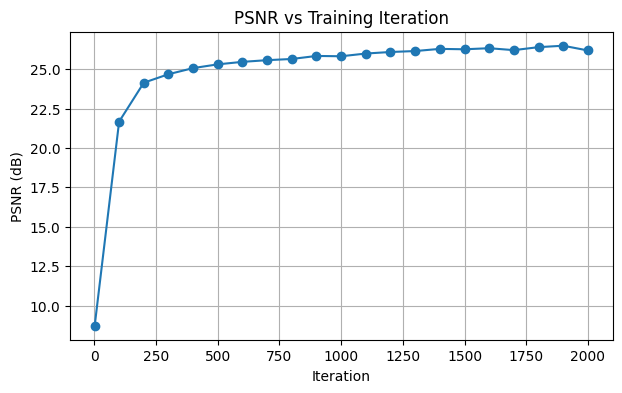

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(history["eval_iter"], history["eval_psnr"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs Training Iteration")
plt.grid(True)
plt.show()

## 9. 2×2 grid over positional encoding frequency and width

- **2 choices of max positional encoding frequency**
- **2 choices of width**

The cell below runs that experiment and shows the 2×2 grid.

In [22]:

def run_grid_experiments(
    image_np,
    L_values=(4, 10),
    width_values=(64, 256),
    lr=1e-2,
    batch_size=10000,
    num_iters=1200,
    eval_every=200,
):
    results = {}

    for L in L_values:
        for width in width_values:
            print(f"Running experiment: L={L}, width={width}")

            _, hist, _, final_img, final_psnr = train_neural_field(
                image_np,
                num_freqs=L,
                hidden_dim=width,
                lr=lr,
                batch_size=batch_size,
                num_iters=num_iters,
                eval_every=eval_every,
                checkpoint_steps=(num_iters,),
            )

            results[(L, width)] = {
                "image": final_img,
                "psnr": final_psnr,
                "history": hist,
            }

    return results


def plot_grid_results(results, L_values, width_values):
    fig, axes = plt.subplots(len(L_values), len(width_values), figsize=(5 * len(width_values), 5 * len(L_values)))

    if len(L_values) == 1 and len(width_values) == 1:
        axes = np.array([[axes]])
    elif len(L_values) == 1:
        axes = np.array([axes])
    elif len(width_values) == 1:
        axes = np.array([[ax] for ax in axes])

    for i, L in enumerate(L_values):
        for j, width in enumerate(width_values):
            ax = axes[i, j]
            result = results[(L, width)]
            ax.imshow(result["image"])
            ax.set_title(f"L={L}, width={width}\nPSNR={result['psnr']:.2f}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


Running experiment: L=4, width=64
iter  400 | batch MSE: 0.008339 | batch PSNR: 20.79 | full PSNR: 20.86
iter  800 | batch MSE: 0.004843 | batch PSNR: 23.15 | full PSNR: 23.24
iter 1200 | batch MSE: 0.004591 | batch PSNR: 23.38 | full PSNR: 23.73
iter 1600 | batch MSE: 0.004523 | batch PSNR: 23.45 | full PSNR: 23.52
iter 2000 | batch MSE: 0.003862 | batch PSNR: 24.13 | full PSNR: 24.16
Running experiment: L=4, width=256
iter  400 | batch MSE: 0.004842 | batch PSNR: 23.15 | full PSNR: 23.32
iter  800 | batch MSE: 0.003871 | batch PSNR: 24.12 | full PSNR: 24.12
iter 1200 | batch MSE: 0.003447 | batch PSNR: 24.63 | full PSNR: 24.44
iter 1600 | batch MSE: 0.003363 | batch PSNR: 24.73 | full PSNR: 24.79
iter 2000 | batch MSE: 0.003463 | batch PSNR: 24.61 | full PSNR: 24.85
Running experiment: L=10, width=64
iter  400 | batch MSE: 0.003801 | batch PSNR: 24.20 | full PSNR: 24.22
iter  800 | batch MSE: 0.003670 | batch PSNR: 24.35 | full PSNR: 24.50
iter 1200 | batch MSE: 0.003138 | batch PSNR

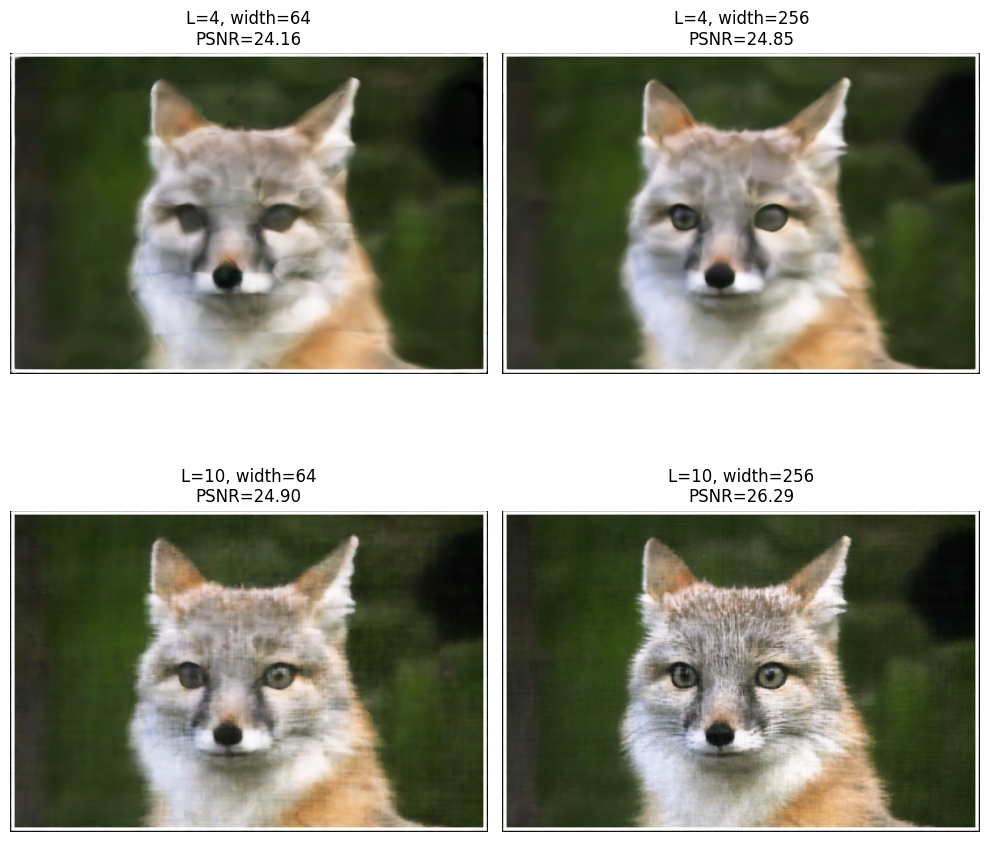

In [25]:
# Default choices:
# - low PE frequency: 4
# - high PE frequency: 10
# - narrow width: 64
# - wide width: 256

L_values = (4, 10)
width_values = (64, 256)

grid_results = run_grid_experiments(
    image_np,
    L_values=L_values,
    width_values=width_values,
    lr=1e-2,
    batch_size=10000,
    num_iters=2000,
    eval_every=400,
)

plot_grid_results(grid_results, L_values, width_values)

## 10. Training on my image

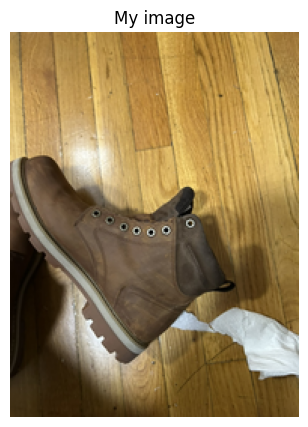

iter    1 | batch MSE: 0.062223 | batch PSNR: 12.06 | full PSNR: 11.10
iter  100 | batch MSE: 0.002419 | batch PSNR: 26.16 | full PSNR: 26.54
iter  400 | batch MSE: 0.001041 | batch PSNR: 29.82 | full PSNR: 30.03
iter  500 | batch MSE: 0.001200 | batch PSNR: 29.21 | full PSNR: 29.59
iter  800 | batch MSE: 0.000867 | batch PSNR: 30.62 | full PSNR: 30.90
iter 1000 | batch MSE: 0.000878 | batch PSNR: 30.56 | full PSNR: 31.53
iter 1200 | batch MSE: 0.000527 | batch PSNR: 32.78 | full PSNR: 33.06
iter 1600 | batch MSE: 0.000424 | batch PSNR: 33.72 | full PSNR: 33.70
iter 2000 | batch MSE: 0.000427 | batch PSNR: 33.70 | full PSNR: 33.60
My image final PSNR: 33.60 dB


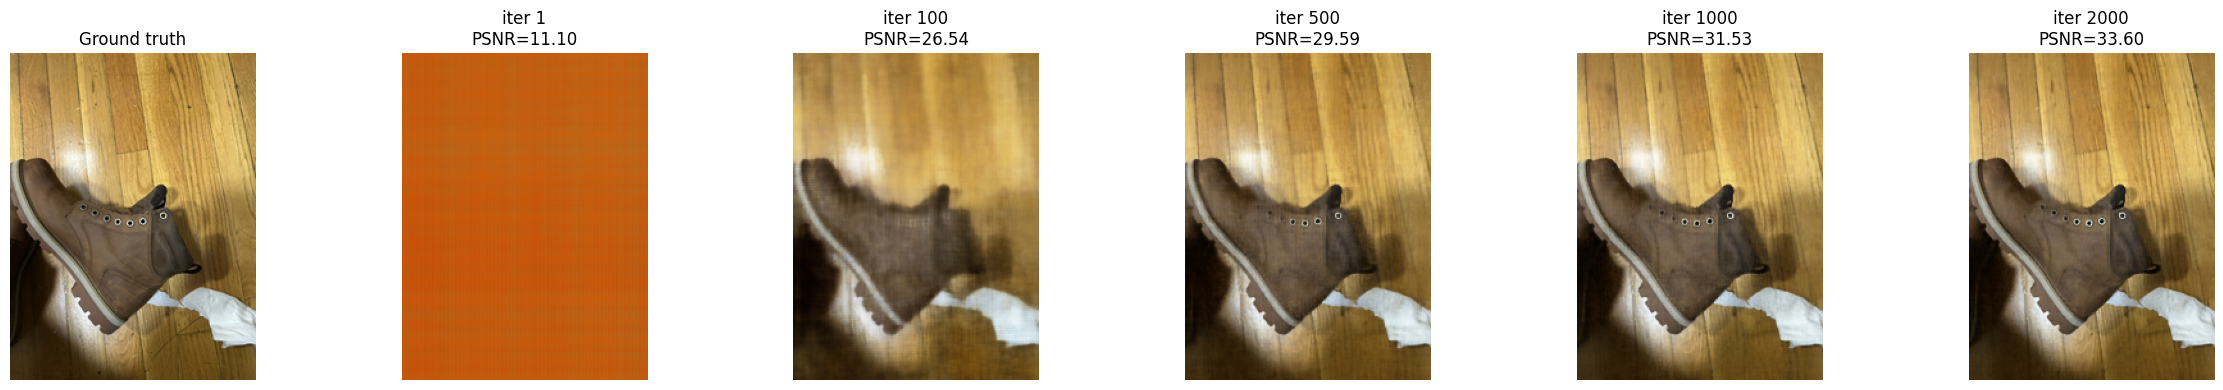

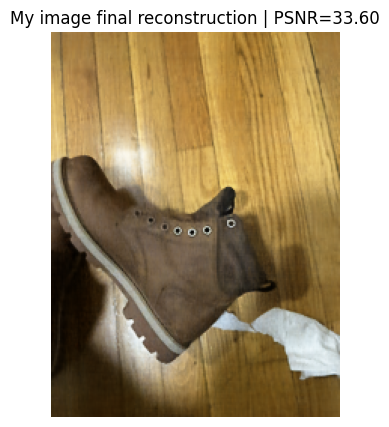

In [27]:

MY_IMAGE_PATH = "data/boot.jpeg"
MY_MAX_DIM = 256

my_image_np = load_image(MY_IMAGE_PATH, MY_MAX_DIM)
show_image(my_image_np, title="My image")

my_model, my_history, my_checkpoints, my_final_recon, my_final_psnr = train_neural_field(
    my_image_np,
    num_freqs=10,
    hidden_dim=256,
    lr=1e-2,
    batch_size=10000,
    num_iters=2000,
    eval_every=400,
    checkpoint_steps=(1, 100, 500, 1000, 2000),
)

print(f"My image final PSNR: {my_final_psnr:.2f} dB")
show_progress_grid(my_image_np, my_checkpoints)
show_image(my_final_recon, title=f"My image final reconstruction | PSNR={my_final_psnr:.2f}")


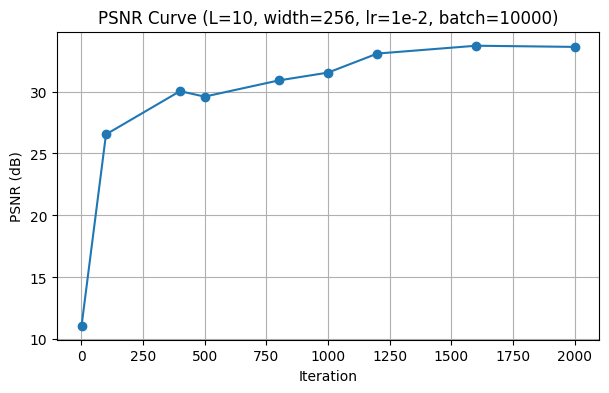

In [28]:
plt.figure(figsize=(7, 4))
plt.plot(my_history["eval_iter"], my_history["eval_psnr"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("PSNR (dB)")
plt.title("PSNR Curve (L=10, width=256, lr=1e-2, batch=10000)")
plt.grid(True)
plt.show()

## Model Architecture and Training Setup

I used a 2D neural field that maps pixel coordinates $(x, y)$ to RGB color values $(r, g, b)$. The input coordinates were first passed through sinusoidal positional encoding with maximum frequency level $L = 10$. The encoded coordinates were then fed into a multilayer perceptron with **3 hidden layers**, each of width **256**. ReLU was used after each hidden layer, and a Sigmoid activation was used at the output layer so that the predicted RGB values stayed in the range $[0,1]$.

The model was trained using **MSE loss** and the **Adam optimizer** with a learning rate of **1e-2**. The batch size was **10000**, and the network was trained for **2000 iterations**.

### Hyperparameters
- **Number of hidden layers:** 3
- **Hidden width:** 256
- **Positional encoding frequency $L$:** 10
- **Learning rate:** 1e-2
- **Batch size:** 10000
- **Number of iterations:** 2000

### PSNR Curve Settings
For the PSNR curve, I used the following hyperparameters: $L = 10$, hidden width $= 256$, number of hidden layers $= 3$, learning rate $= 1e-2$, batch size $= 10000$, and number of iterations $= 2000$.